In [1]:
import numpy as np
import pandas as pd

In [2]:
results_path = "/scratch1/smaruj/background_generation/seqpro_shuffling_finetuned.tsv"

In [3]:
df = pd.read_csv(results_path, sep="\t")

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

Text(0, 0.5, 'Predicted Map Signal Strength')

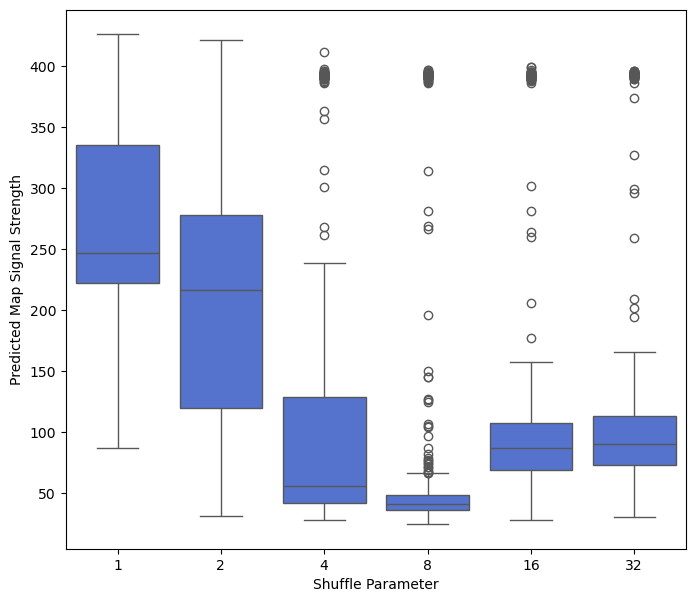

In [5]:
# boxplot by shulffle paramterer
plt.figure(figsize=(8, 7))
sns.boxplot(data=df, x="shuffle_parameter", y="scd", color="royalblue")

plt.xlabel("Shuffle Parameter")
plt.ylabel("Predicted Map Signal Strength")

# plt.savefig("disruption_score_vs_shuffle_parameter.pdf", format="pdf", bbox_inches="tight")

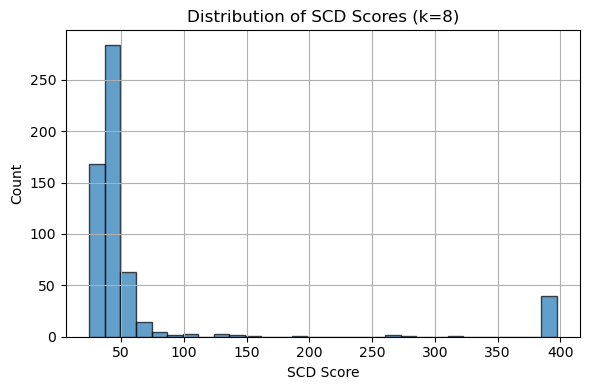

In [6]:
# Filter the SCD values where shuffle_parameter == 8
scd_values = df[df["shuffle_parameter"] == 8]["scd"]

# Plot
plt.figure(figsize=(6, 4))
plt.hist(scd_values, bins=30, edgecolor='black', alpha=0.7)
plt.title("Distribution of SCD Scores (k=8)")
plt.xlabel("SCD Score")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Predicted Map Signal Strength')

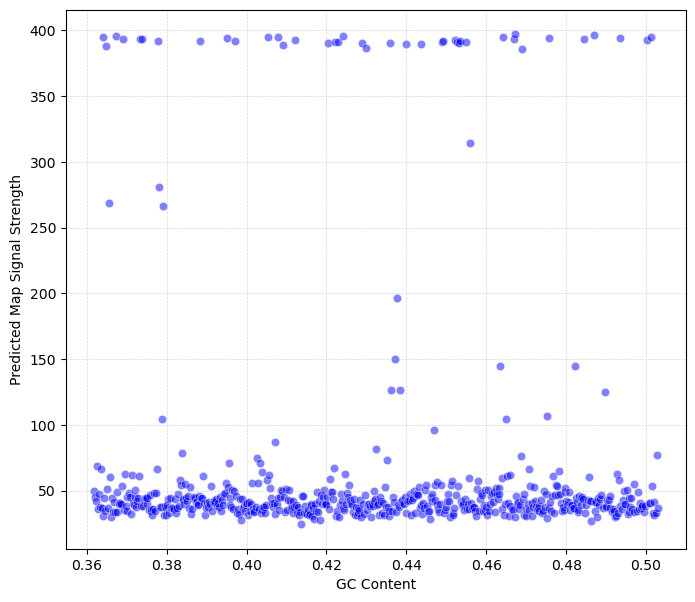

In [7]:
plt.figure(figsize=(8, 7))
plt.scatter(df[df["shuffle_parameter"] == 8]["GC_content"], df[df["shuffle_parameter"] == 8]["scd"], alpha=0.5, edgecolors='w', linewidth=0.5, color='blue')

# Adding grid for better readability
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)

plt.xlabel("GC Content")
plt.ylabel("Predicted Map Signal Strength")

# plt.savefig("disruption_score_vs_gc_content.pdf", format="pdf", bbox_inches="tight")

In [8]:
k8 = df[df["shuffle_parameter"] == 8]
len(k8[k8["scd"] > 300]) / len(k8["scd"])

0.06949152542372881

In [9]:
k8["total_var"].min()

985.36316

Text(0, 0.5, 'Local Standard Deviation')

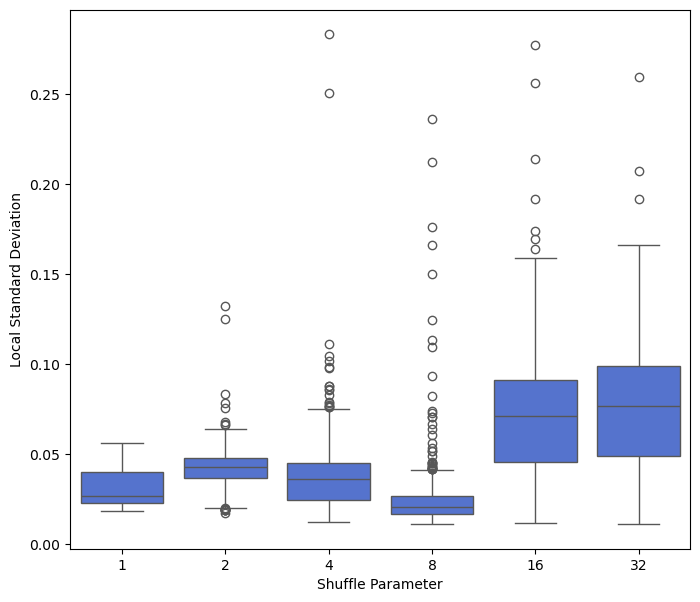

In [10]:
# boxplot by shulffle paramterer
plt.figure(figsize=(8, 7))
sns.boxplot(data=df, x="shuffle_parameter", y="local_std", color="royalblue")

plt.xlabel("Shuffle Parameter")
plt.ylabel("Local Standard Deviation")

# plt.savefig("disruption_score_vs_shuffle_parameter.pdf", format="pdf", bbox_inches="tight")

Text(0, 0.5, 'Total variation')

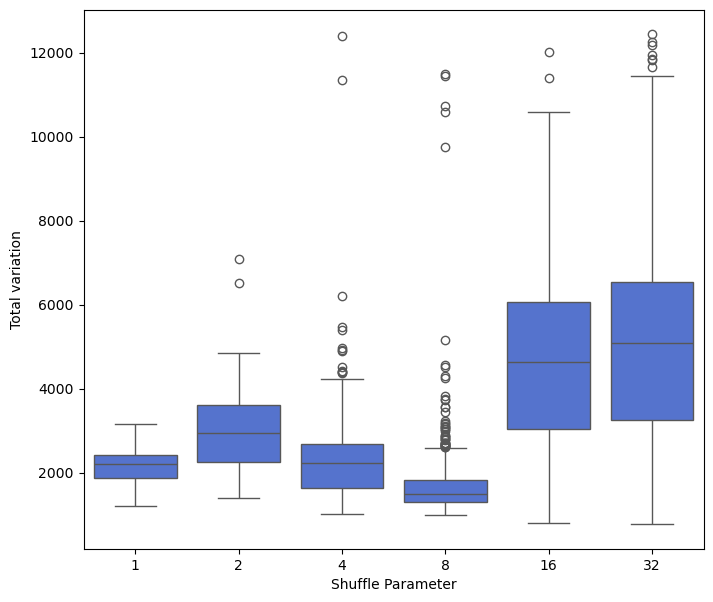

In [11]:
# boxplot by shulffle paramterer
plt.figure(figsize=(8, 7))
sns.boxplot(data=df, x="shuffle_parameter", y="total_var", color="royalblue")

plt.xlabel("Shuffle Parameter")
plt.ylabel("Total variation")

# plt.savefig("disruption_score_vs_shuffle_parameter.pdf", format="pdf", bbox_inches="tight")

### Comparing with random shuffling and the transferred model

In [12]:
random_df = pd.read_csv("/scratch1/smaruj/background_generation/random_shuffling_finetuned.tsv", sep="\t")

In [13]:
transferred_df = pd.read_csv("/scratch1/smaruj/background_generation/random_shuffling_transferred.tsv", sep="\t")

In [14]:
# Add a column to label the method
df["method"] = "seqpro, fine-tuned"
random_df["method"] = "random, fine-tuned"
transferred_df["method"] = "random, transferred"

# Combine both dataframes
combined_df = pd.concat([df, random_df, transferred_df], ignore_index=True)

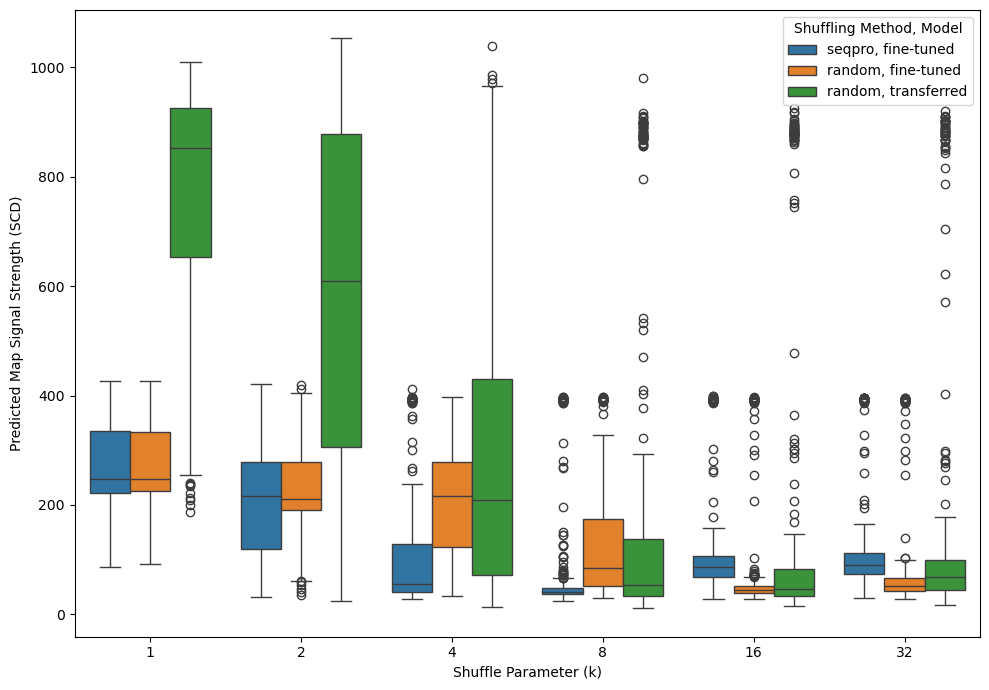

In [16]:
# Create the plot
plt.figure(figsize=(10, 7))
sns.boxplot(data=combined_df, x="shuffle_parameter", y="scd", hue="method")

plt.xlabel("Shuffle Parameter (k)")
plt.ylabel("Predicted Map Signal Strength (SCD)")
plt.legend(title="Shuffling Method, Model")
plt.tight_layout()
plt.show()